## 1. Import Library

In [1]:
import sys
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns
from itertools import combinations
from IPython.display import display

Tahap pertama yang kita lakukan adalah memanggil semua *library* pendukung yang dibutuhkan dalam proses pengolahan citra dan klasifikasi. Di sini kita menggunakan `cv2` (OpenCV) dan `skimage` untuk mengolah gambar dan mengekstrak fitur teksturnya. Untuk perhitungan matriks, kita memakai `numpy`, sedangkan `pandas` akan kita gunakan untuk menyusun hasil ekstraksi menjadi tabel data yang rapi. Selain itu, kita juga mengimpor algoritma *Machine Learning* seperti Random Forest, SVM, dan KNN dari `scikit-learn` beserta alat ukur akurasinya. Terakhir, `matplotlib` dan `seaborn` disiapkan untuk menampilkan visualisasi grafik.

## 2. Cek Kemiripan Gambar (Duplikasi)

Sebelum mengolah data, ada baiknya kita memastikan tidak ada data gambar yang kembar identik (duplikat). Jika algoritma belajar dari gambar yang persis sama berulang-ulang, ia bisa jadi "menghafal" dan bukan benar-benar belajar (*overfitting*).

Kode di bawah ini akan mengecilkan ukuran semua gambar dari salah satu kelas (sebagai contoh) menjadi 64x64 piksel agar lebih cepat diproses. Kemudian, ia membandingkan selisih nilai antar gambarnya. Jika selisihnya di bawah 5.0, sistem akan menganggap gambar tersebut sangat mirip atau duplikat. Output cetak di bawah ini akan melaporkan apakah ada gambar yang terdeteksi mirip.

In [2]:
folder = "dataset/Grape_black_rot_100"
files = sorted(os.listdir(folder))

thumbs = {}
for fname in files:
    img = cv.imread(os.path.join(folder, fname), cv.IMREAD_GRAYSCALE)
    if img is not None:
        thumbs[fname] = cv.resize(img, (64, 64)).astype(np.float32)

THRESHOLD = 5.0  # makin kecil, makin ketat syarat "dianggap mirip"

for f1, f2 in combinations(thumbs.keys(), 2):
    diff = np.mean(np.abs(thumbs[f1] - thumbs[f2]))
    if diff < THRESHOLD:
        print(f"MIRIP (selisih={diff:.2f}):", f1, "<->", f2)

MIRIP (selisih=0.00): Grape_Black_rot10005.jpg <-> Grape_Black_rot10114.jpg
MIRIP (selisih=0.24): Grape_Black_rot10007.jpg <-> Grape_Black_rot10009.jpg
MIRIP (selisih=0.00): Grape_Black_rot10104.jpg <-> Grape_Black_rot10118.jpg
MIRIP (selisih=0.00): Grape_Black_rot10105.jpg <-> Grape_Black_rot10117.jpg
MIRIP (selisih=0.19): Grape_Black_rot10106.jpg <-> Grape_Black_rot10110.jpg
MIRIP (selisih=0.19): Grape_Black_rot10107.jpg <-> Grape_Black_rot10109.jpg
MIRIP (selisih=0.02): Grape_Black_rot10120.jpg <-> Grape_Black_rot10131.jpg
MIRIP (selisih=0.02): Grape_Black_rot10121.jpg <-> Grape_Black_rot10130.jpg
MIRIP (selisih=0.24): Grape_Black_rot10122.jpg <-> Grape_Black_rot10127.jpg
MIRIP (selisih=0.24): Grape_Black_rot10123.jpg <-> Grape_Black_rot10126.jpg
MIRIP (selisih=0.00): Grape_Black_rot10617.jpg <-> Grape_Black_rot10629.jpg
MIRIP (selisih=0.00): Grape_Black_rot10618.jpg <-> Grape_Black_rot10628.jpg
MIRIP (selisih=0.16): Grape_Black_rot10637.jpg <-> Grape_Black_rot10642.jpg
MIRIP (selis

## 3. Load Dataset

Langkah selanjutnya adalah memuat gambar dataset utama ke dalam memori program. Kode di bawah ini akan membuka folder `dataset` dan membaca setiap sub-folder di dalamnya. Nama dari sub-folder tersebut otomatis dijadikan sebagai label kelas (misalnya, daun dengan *Black Rot* atau daun sehat). 

Setiap gambar yang berhasil dibaca akan disimpan dalam *array* `data`, dan labelnya disimpan dalam *array* `labels`. Jika ada gambar yang rusak, sistem akan otomatis melewatinya. Output di bawah ini akan menampilkan total keseluruhan gambar yang berhasil dimuat beserta daftar kelas yang ditemukan, untuk memastikan semua data sudah masuk dengan benar.

In [3]:
data = []
labels = []
file_name = []

for sub_folder in os.listdir("dataset"):
    sub_folder_path = os.path.join("dataset", sub_folder)
    if os.path.isdir(sub_folder_path):
        sub_folder_files = os.listdir(sub_folder_path)
        for i, filename in enumerate(sub_folder_files):
            img_path = os.path.join(sub_folder_path, filename)
            img = cv.imread(img_path)

            if img is None:
                continue

            data.append(img)
            labels.append(sub_folder)
            file_name.append(f"{sub_folder}_{i+1}.jpg")

print(f"Total gambar yang dimuat: {len(data)}")
print(f"Daftar kelas yang ditemukan: {sorted(set(labels))}")

Total gambar yang dimuat: 200
Daftar kelas yang ditemukan: ['Grape_black_rot_100', 'daun_sehat_100']


## 4. Inisialisasi Augmentasi Data

Pada beberapa kasus *Machine Learning*, jika jumlah data kita terlalu sedikit, kita biasanya melakukan *Augmentasi* (memperbanyak variasi gambar dengan cara diputar atau dibalik).

Blok kode di bawah ini disiapkan sebagai wadah (*placeholder*) jika sewaktu-waktu kita ingin menambahkan teknik augmentasi tersebut. Untuk saat ini, fungsi utamanya hanya untuk mencatat dan membandingkan jumlah data sebelum dan sesudah diproses. Outputnya akan mencetak konfirmasi bahwa saat ini tidak ada penambahan data buatan yang dimasukkan ke dalam sistem.

In [4]:
data_augmented = []
labels_augmented = []
paths_augmented = []
file_name_augmented = []

for i in range(len(data)):
	pass

print("Data sebelum augmentasi: ", len(data))
print("Data setelah augmentasi: ", len(data_augmented))

Data sebelum augmentasi:  200
Data setelah augmentasi:  0


## 5. Definisi Pipeline Preprocessing

In [5]:
TARGET_SIZE = (256, 256)

def gray(image, target_size=TARGET_SIZE):
    resized = cv.resize(image, target_size)
    if len(resized.shape) == 3:
        gray_img = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray_img = resized
    return gray_img.astype(np.uint8)


def median(image_input, kernel_size=5):
    if isinstance(image_input, str):
        img = cv.imread(image_input, cv.IMREAD_GRAYSCALE)
    else:
        img = image_input.copy()

    pad_size = kernel_size // 2
    padded = np.pad(img, pad_size, mode='constant')
    height, width = img.shape
    K = kernel_size * kernel_size

    windows = np.zeros((K, height, width), dtype=np.uint8)
    idx = 0
    for di in range(kernel_size):
        for dj in range(kernel_size):
            windows[idx] = padded[di:di+height, dj:dj+width]
            idx += 1

    half = (K + 1) // 2
    cum_count = np.zeros((height, width), dtype=np.int32)
    median_result = np.zeros((height, width), dtype=np.uint8)
    selesai = np.zeros((height, width), dtype=bool)

    for v in range(256):
        count_v = np.sum(windows == v, axis=0)
        cum_count = cum_count + count_v
        baru_capai = (cum_count >= half) & (~selesai)
        median_result[baru_capai] = v
        selesai = selesai | baru_capai

    return median_result.astype(np.uint8)


def histogram_equalization(image_input):
    if isinstance(image_input, str):
        img = cv.imread(image_input, cv.IMREAD_GRAYSCALE)
    else:
        img = image_input.copy()

    L = 256
    counts, _ = np.histogram(img, bins=L, range=(0, L))
    cdf = np.cumsum(counts)

    cdf_min = np.min(cdf[cdf > 0])
    total_pixel = np.sum(counts)

    mapping = np.round((cdf - cdf_min) / (total_pixel - cdf_min) * (L - 1))
    mapping = np.clip(mapping, 0, L - 1)

    equalized_result = mapping[img].astype(np.uint8)
    return equalized_result

def prepro(image):
    img1 = gray(image)
    img2 = median(img1)
    img3 = histogram_equalization(img2)
    return img1, img2, img3

def run_prepro(image):
    _, _, final_img = prepro(image)
    return final_img

Sebelum mulai mengambil ciri tekstur dari daun, gambar mentah perlu melalui proses *preprocessing* agar informasi bentuk tepi daun menjadi lebih jelas dan *noise* (gangguan kecil pada gambar) bisa dikurangi. Pada percobaan pertama (pipeline 1) ini, kita hanya menggunakan tiga tahapan dasar tanpa penajaman tepi matriks:
1. `gray`: Mengubah ukuran gambar menjadi standar 256x256 piksel dan membuang warna aslinya menjadi hitam-putih (*Grayscale*), agar sistem fokus pada analisis tekstur.
2. `median`: Menggunakan *Median Filter* untuk menghaluskan gambar dan mengurangi bintik-bintik *noise* tanpa merusak bentuk batas asli dari daun.
3. `histogram_equalization`: Meratakan kontras gambar sehingga perbedaan antara bagian yang terang dan gelap menjadi jauh lebih tegas dan tajam.
Semua tahapan ini digabungkan secara berurutan ke dalam fungsi utama bernama `prepro`.

## 6. Visualisasi Hasil Preprocessing

Untuk melihat langsung bagaimana fungsi *preprocessing* ini bekerja pada gambar daun kita, kode di bawah akan mengambil beberapa contoh acak dari setiap kelas dan memprosesnya langkah demi langkah.

Saat kode ini dijalankan,  akan disuguhi sekumpulan gambar hasil proses yang tersusun rapi.  bisa membandingkan perubahannya: dari yang tadinya format *Grayscale*, kemudian dihaluskan melalui *Median*, hingga akhirnya kontras warnanya ditegaskan melalui *Equalisasi*. Karena kita tidak menggunakan operator deteksi tepi seperti Sobel pada percobaan ini, gambar hasil akhir masih berupa wujud utuh daun dengan kontras warna yang sangat pekat. Perbedaan bercak infeksi pada daun sakit bisa langsung dikenali melalui warna gelap yang sangat kontras menonjol.

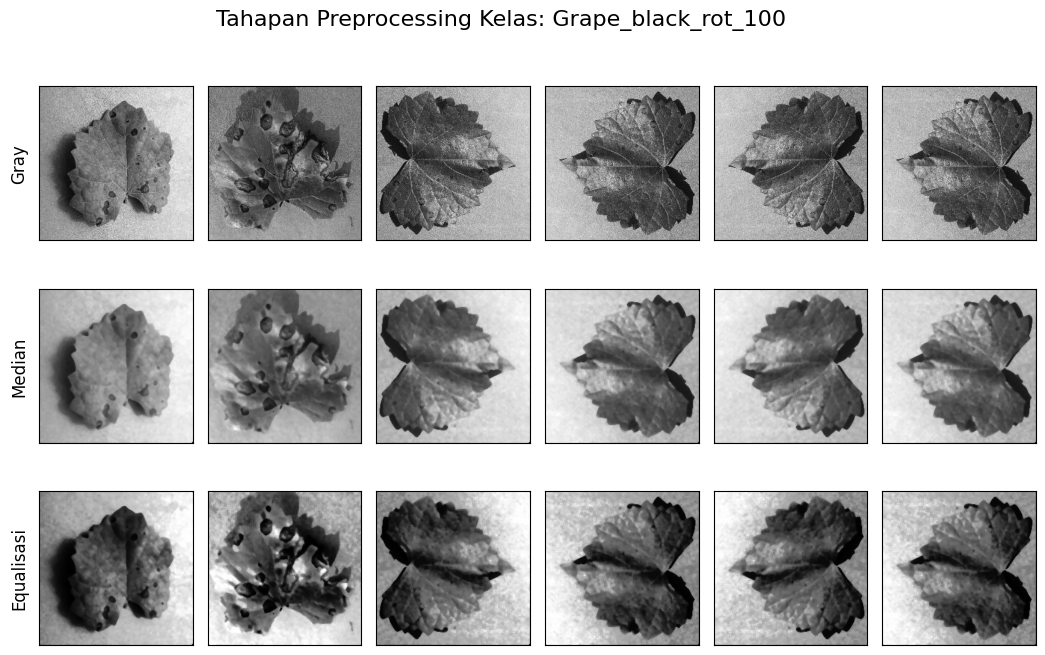

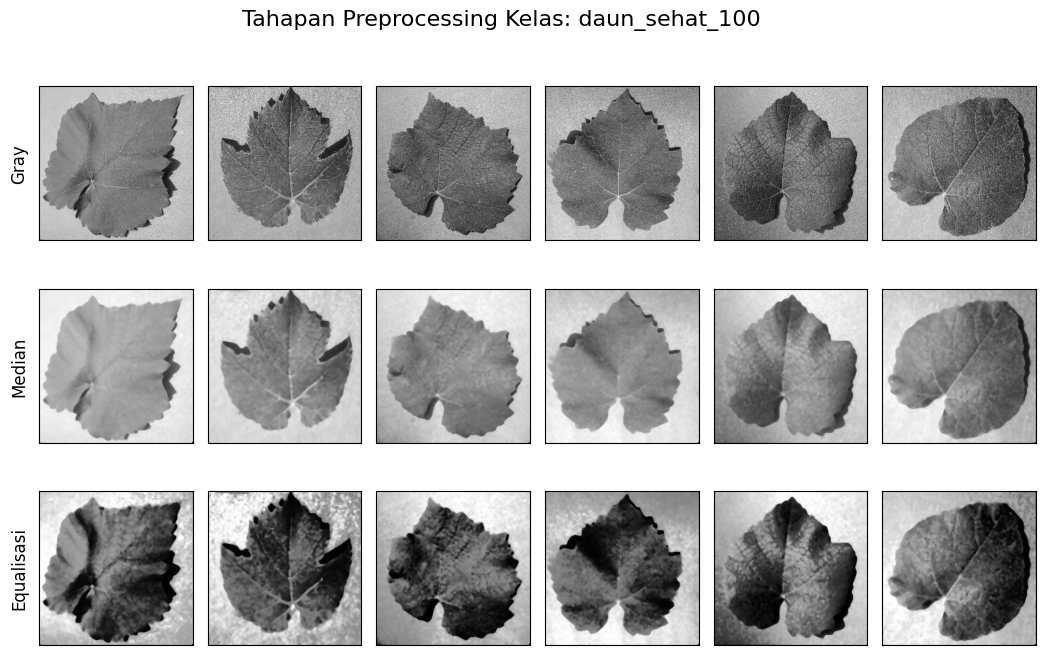

In [6]:
dataPreprocessed = [run_prepro(img) for img in data]
unique_labels = sorted(set(labels))
nama_step = ['Gray', 'Median', 'Equalisasi']

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]
    n_sample = min(6, len(idxs))

    fig, axs = plt.subplots(3, 6, figsize=(11, 7))
    fig.suptitle(f'Tahapan Preprocessing Kelas: {label}', fontsize=16)

    for k in range(n_sample):
        img_asli = data[idxs[k]]
        hasil_tahap = prepro(img_asli)
        
        for row in range(3):
            axs[row][k].imshow(hasil_tahap[row], cmap='gray')
            axs[row][k].set_xticks([])
            axs[row][k].set_yticks([])
            if k == 0:
                axs[row][k].set_ylabel(nama_step[row], fontsize=12, labelpad=8)

    for k in range(n_sample, 6):
        for row in range(3):
            axs[row][k].axis('off')

    plt.tight_layout(rect=[0.04, 0, 1, 1])
    plt.subplots_adjust(top=0.92)
    plt.show()

## 7. Definisi Fungsi Feature Extraction GLCM

In [7]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Angle harus 0, 45, 90, atau 135.")
    
    glcm_matrix = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm_matrix

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

Setelah proses peningkatan kontras usai, tahap krusial selanjutnya adalah mengekstrak tekstur matematis menggunakan metode *Gray-Level Co-occurrence Matrix* (GLCM). Fungsi `glcm` bertugas menyusun matriks probabilitas kejadian piksel-piksel yang bersebelahan.

Dari matriks probabilitas tersebut, kode di atas mendefinisikan tujuh metrik perhitungan. `Correlation` meninjau pola struktur linier jaringan daun. `Contrast` dan `Dissimilarity` menghitung nilai intensitas kekasaran tekstur (bercak infeksi daun akan menyumbang nilai yang tinggi). `Homogeneity` menangkap seberapa mulus permukaan gambar. `ASM` dan `Energy` berfungsi menakar dominasi konsistensi warna yang ada, dan terakhir, `Entropy` akan mengukur seberapa acak dan rusaknya susunan warna di area gambar akibat patogen jamur.

## 8. Komputasi Matriks Probabilitas Multi-Sudut

In [8]:
Derajat0, Derajat45, Derajat90, Derajat135 = [], [], [], []

for img in dataPreprocessed:
    Derajat0.append(glcm(img, 0))
    Derajat45.append(glcm(img, 45))
    Derajat90.append(glcm(img, 90))
    Derajat135.append(glcm(img, 135))

Titik infeksi dan bentuk guratan tulang daun umumnya menjalar tak beraturan. Jika sistem hanya mengandalkan perhitungan dari satu sumbu pengamatan, akurasi akan menurun secara signifikan. Oleh karenanya, blok iterasi matriks di atas diprogram untuk menghitung fungsi probabilitas dari empat sudut mata angin (0, 45, 90, dan 135 derajat) secara serempak. Array-array matriks tersebut disimpan untuk kemudian dikalkulasikan nilainya.

## 9. Inisialisasi Array Feature Extraction

In [9]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

Sebagai langkah prosedural sebelum penggalian 7 nilai fitur matematis pada keempat sudut tadi dilakukan, blok kode ini bertugas mendeklarasikan 28 keranjang (*list array*) kosong di dalam memori. Variabel-variabel inilah yang nanti akan menampung setiap angka hasil perhitungan agar posisinya tak saling bergeser dan tertata valid secara sistematis.

## 10. Feature Extraction: Correlation

In [10]:
for i in range(len(dataPreprocessed)):
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))

Langkah awal dari proses analisis fitur (*Feature Extraction*) dijalankan pada parameter `Correlation` (Korelasi). Algoritma ini berjalan otomatis di balik layar untuk menilai linearitas pola tekstur daun. Nilai ini sangat baik untuk menyorot kepadatan dan arah struktur alami jaringan serat pada daun segar yang sehat.

## 11. Feature Extraction: Contrast

In [11]:
for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

Tahapan yang kedua membedah khusus nilai `Contrast` (Kekontrasan). Karena sifat perhitungannya yang melonjak (*eksponensial*) saat bertemu gradasi piksel tajam, fitur ini sangat krusial dalam mendeteksi dan memberi bobot rasio pada bintik pekat dari *Black Rot* yang muncul bertebaran menumpuk di area hijau spesimen.

## 12. Feature Extraction: Dissimilarity

In [12]:
for i in range(len(dataPreprocessed)):
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

Di urutan ketiga kita menarik data indeks `Dissimilarity` (Ketidaksamaan). Kendati cara kerjanya mirip dengan penarikan nilai `Contrast`, pengukuran ini tidak mendramatisasi perbedaan nilai matriks (linier). Kemampuannya menstabilkan deviasi sangat berguna meraba tingkat kekasaran (*coarseness*) ringan yang sering ditemui pada transisi tepi pinggiran daun biasa.

## 13. Feature Extraction: Homogeneity

In [13]:
for i in range(len(dataPreprocessed)):
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

Modul keempat menangani analisis indikator `Homogeneity` (Homogenitas). Di sini mesin akan berfokus melihat seberapa rata penyebaran rona visual pada lembaran objek. Kelompok tanaman sampel daun sehat pastinya membukukan skor homogenitas puncak karena kutikulanya belum banyak dirusak bercak.

## 14. Feature Extraction: Entropy

In [14]:
for i in range(len(dataPreprocessed)):  
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

Pada perhitungan ini, matriks dievaluasi menggunakan indeks `Entropy` (Entropi). Nilai entropi menjaring probabilitas seberapa berantakan suatu elemen spasial (*noise*) pada suatu daun. Jika gambar menunjukkan banyak rintik cacat bercak jamur yang tersebar acak secara tidak harmonis, angka pengembalian nilai entropinya niscaya membengkak.

## 15. Feature Extraction: ASM

In [15]:
for i in range(len(dataPreprocessed)):
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

Perhitungan parameter yang keenam mengobservasi nilai `Angular Second Moment` (ASM). Kalkulasi matematis dari fungsi ini mencatat penguasaan konsistensi pola dari kelompok-kelompok titik yang homogen di permukaan daun, membantu algoritma mengenali keseimbangan dan keseragaman identitas objek aslinya.

## 16. Feature Extraction: Energy

In [16]:
for i in range(len(dataPreprocessed)):
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

Ekstraksi matriks GLCM yang terakhir mengukur nilai `Energy` (Energi). Properti spesifik ini dikalkulasi langsung dengan menarik akar kuadrat dari bilangan indeks ASM. Hal ini semata-mata dilakukan guna memadatkan rentang bilangan agar terdistribusi dalam bentuk pecahan yang lebih efisien dan tidak memberatkan komputasi.

## 17. Pembentukan DataFrame

Keseluruhan 28 elemen nilai tekstur yang diekstrak tadi belum layak dicerna algoritma selagi posisinya masih tercerai-berai secara matriks. Oleh karenanya, struktur manajemen data amat diperlukan pada tahap komputasi ini.

Melalui library *pandas*, puluhan array kolom fitur tersebut dijahit berdampingan menjadi format *DataFrame*. Penambahan atribut vital seperti pengenal asal (*Filename*) dan penamaan jenis observasi botani (*Label*) juga dilakukan. Setelah blok ini dijalankan, *output* tabel langsung memunculkan tampilan visual dataset tabular awal yang kini sangat rapi dan siap saji.

In [17]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
display(df.head())

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,daun_sehat_100_1.jpg,daun_sehat_100,169.127344,279.243214,152.665242,233.056671,0.453145,0.352799,0.460712,0.361176,...,0.004476,0.003261,0.066354,0.056344,0.066899,0.057110,0.984527,0.974498,0.986064,0.978716
1,daun_sehat_100_2.jpg,daun_sehat_100,209.888174,327.340792,183.627221,318.432464,0.350193,0.265098,0.376209,0.269911,...,0.002228,0.001452,0.044623,0.037399,0.047204,0.038106,0.980953,0.970378,0.983339,0.971184
2,daun_sehat_100_3.jpg,daun_sehat_100,152.571415,262.595571,157.199556,242.806167,0.390866,0.286390,0.379956,0.287493,...,0.001581,0.001092,0.040737,0.032926,0.039764,0.033038,0.985921,0.975781,0.985472,0.977606
3,daun_sehat_100_4.jpg,daun_sehat_100,116.216330,195.937686,118.091483,190.150742,0.402490,0.308193,0.404488,0.299065,...,0.001947,0.001315,0.043835,0.036673,0.044119,0.036261,0.989277,0.981925,0.989087,0.982459
4,daun_sehat_100_5.jpg,daun_sehat_100,171.587056,252.432818,130.849862,246.920907,0.356017,0.266798,0.382345,0.275746,...,0.001029,0.000652,0.030640,0.025142,0.032080,0.025540,0.984200,0.976750,0.987940,0.977257


## 18. Feature Selection dengan Threshold Korelasi

Parameter observasi berlebih yang redundan (menduplikasi informasi) justru menjadi kendala yang memberatkan akurasi pengenalan model klasifikasi. Masalah dimensi berlebih (*curse of dimensionality*) ini memicu urgensi diterapkannya tahap pemangkasan atau *Feature Selection*.

Blok validasi fungsi Pearson ini mengawasi relasi antar kolom. Dua variabel yang berbagi koneksi linear sangat identik (bersentuhan di batas r = 0.95) otomatis bakal dieksekusi agar membuang salah satu perwakilannya. Hasil eksekusi `print` membongkar seberapa banyak jumlah variabel optimal yang selamat (*survivor features*). Sebagai pendukung analitis visual, gambar diagram *Heatmap Correlation* yang membiru memperlihatkan bahwa semua variabel yang tersisa kini sudah bersih, stabil, dan independen antar satu sama lain.

Fitur awal (sebelum seleksi)  : 28
Fitur akhir (setelah seleksi) : 11
Fitur fungsional terpilih     : ['Contrast0', 'Contrast45', 'Contrast90', 'Contrast135', 'Homogeneity0', 'Homogeneity90', 'Dissimilarity0', 'Dissimilarity45', 'Dissimilarity90', 'Dissimilarity135', 'Entropy0']


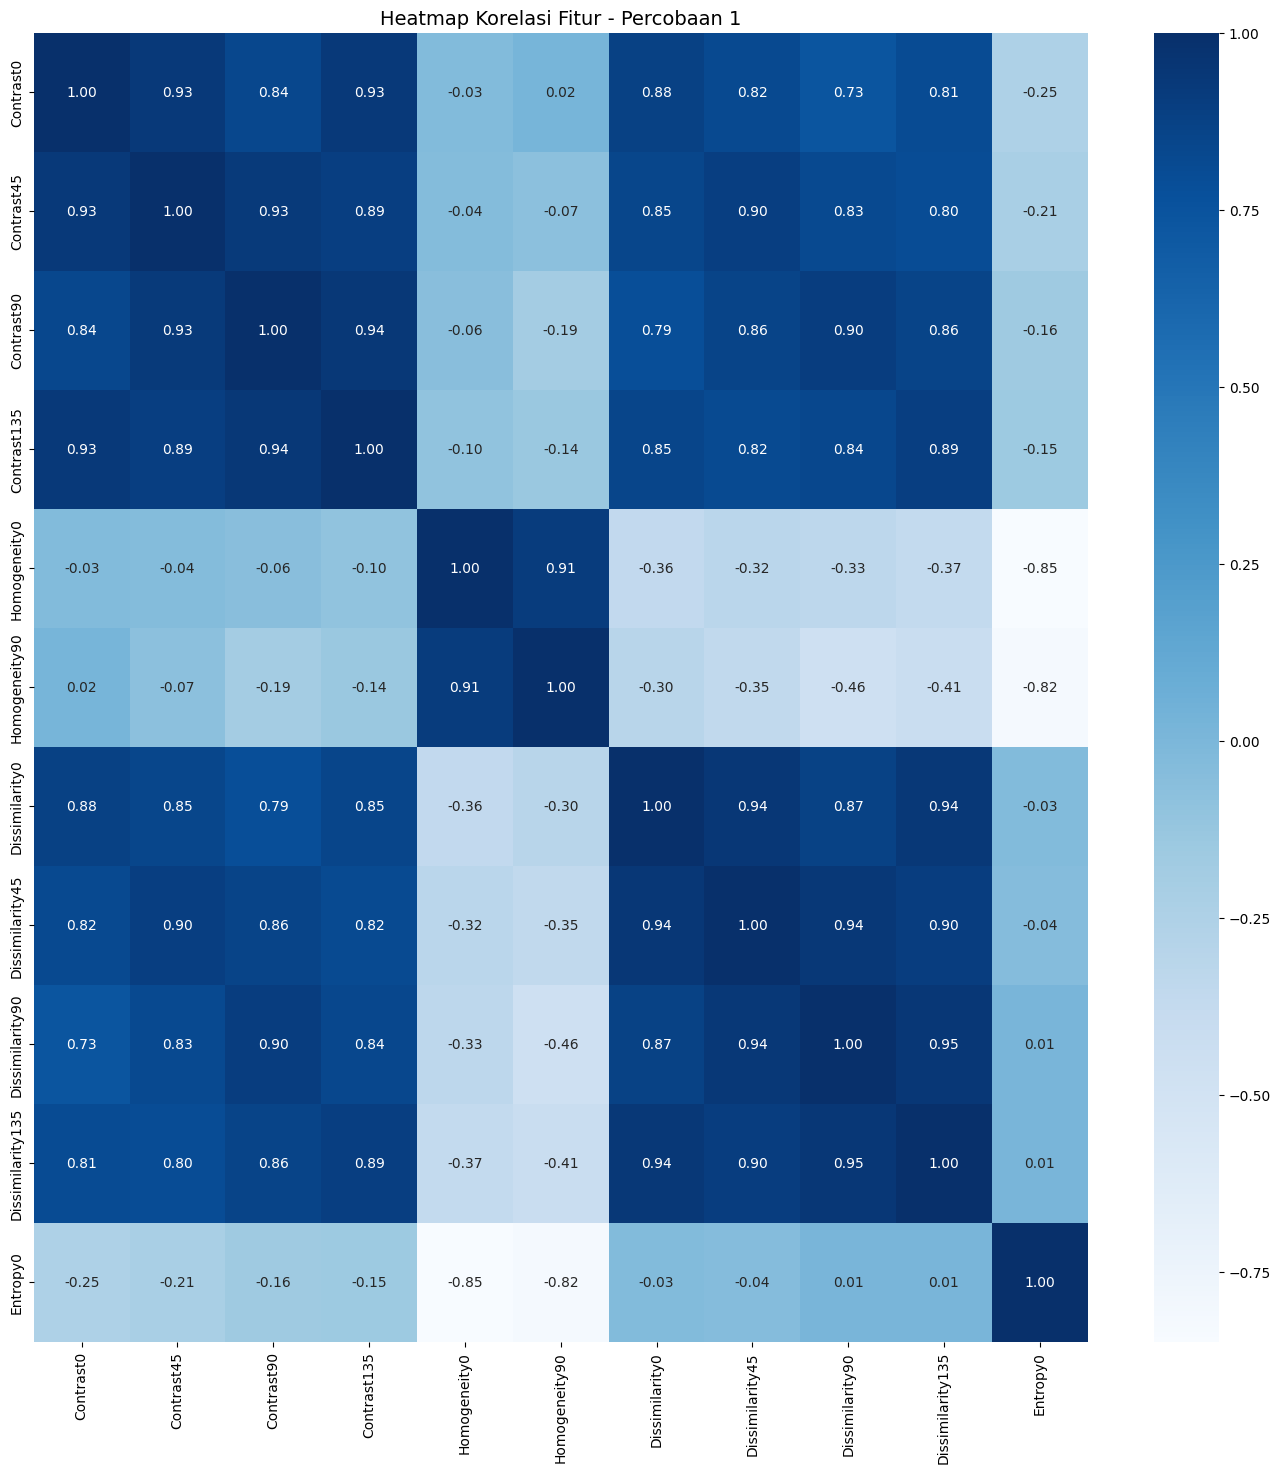

In [18]:
corr_matrix = df.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((corr_matrix.shape[0],), True, dtype=bool)
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if abs(corr_matrix.iloc[i,j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = df.drop(columns=['Label','Filename']).columns[columns]
x_new = df[select]
y = df['Label']

print(f"Fitur awal (sebelum seleksi)  : 28")
print(f"Fitur akhir (setelah seleksi) : {len(select)}")
print(f"Fitur fungsional terpilih     : {list(select)}")

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur - Percobaan 1', fontsize=14)
plt.show()

## 19. Data Splitting (Train & Test)

Untuk menjamin bahwa skor presisi hasil pengenalan bersifat independen dan obyektif, kita wajib mencegah algoritma memecahkan prediksi menggunakan kisi-kisi data yang sudah pernah ia hafalkan sebelumnya. Pemisahan kumpulan observasi pun dilakukan secara tegas.

Modul fungsi `train_test_split` secara proporsional mempartisi seluruh tumpukan data tabel ini menjadi rasio baku 80:20 secara *random*. Komposisi mayoritas (80%) diperuntukkan secara murni kepada model untuk belajar (*Train Data*), dan 20% isolasi data sisanya disimpan mutlak untuk tes evaluasi (*Test Data*). Angka keluaran dari *shape* di blok ini membuktikan pendistribusian matriks yang telah dibelah dengan tepat.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print("Ukuran Set Data Latih (X_train, y_train): ", X_train.shape, y_train.shape)
print("Ukuran Set Data Uji (X_test, y_test)    : ", X_test.shape, y_test.shape)

Ukuran Set Data Latih (X_train, y_train):  (160, 11) (160,)
Ukuran Set Data Uji (X_test, y_test)    :  (40, 11) (40,)


## 20. Feature Normalization (Z-Score)

Dalam komputasi arsitektur KNN maupun metode pemisah kuadratik linear layaknya SVM, keberagaman satuan unit angka (seperti rentang fitur ASM yang amat terpencil dibandingkan rentang Entropi yang tinggi) sangat mudah mengakibatkan bias dominansi pembacaan nilai. 

Fungsi eksekusi *Z-Score Normalization* diimplementasikan untuk menjegal hal tersebut. Skala rentang tiap parameter di-nol-kan rata-ratanya dan diperas hingga simpangan bakunya seragam dan linier bernilai 1. Untuk menghalau kecurangan rasio statistik, pemusatan normalisasi *Z-Score* eksklusif diarahkan terhadap `X_train` semata. Tabel sampel matriks normalisasi (*Train Data*) akan otomatis tercetak di layar seusai proses komputasi.

In [20]:
mean_train = X_train.mean()
std_train  = X_train.std()

X_test  = (X_test  - mean_train) / std_train
X_train = (X_train - mean_train) / std_train

print("Verifikasi hasil distribusi Z-Score Normalization (Train Data):")
display(X_train.head())

Verifikasi hasil distribusi Z-Score Normalization (Train Data):


,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity90,Dissimilarity0,Dissimilarity45,Dissimilarity90,Dissimilarity135,Entropy0
79,0.127561,-0.436449,-0.658873,-0.002821,-0.457746,-0.335789,0.197429,-0.273981,-0.105115,0.315388,0.789560
197,-1.133967,-0.220269,0.355751,-0.368297,-0.135007,-1.225598,-0.961237,-0.068326,0.560823,-0.132887,0.182619
38,1.553994,1.535909,1.397257,1.262772,1.051263,1.095767,1.173130,1.181814,1.088783,1.039582,-1.346193
24,0.873836,0.335294,0.587490,0.913788,-0.008212,-0.057499,0.450697,0.161708,0.315653,0.530255,0.081437
122,-0.443186,-0.411581,-0.095121,-0.102087,-0.017380,0.037458,-0.526800,-0.670992,-0.504733,-0.354665,0.753821


## 21. Inisialisasi Model Klasifikasi

In [21]:
def generateClassificationReport(y_true, y_pred, model_name):
    print(f"=== Laporan Metrik Evaluasi: {model_name} ===")
    print("Classification Report:")
    print(classification_report(y_true, y_pred))
    
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()
    
    print(f"Accuracy Score: {accuracy_score(y_true, y_pred) * 100:.2f}%\n")

rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

Kita sampai di ambang uji tanding! Sebelumnya, blok komputasi fungsional `generateClassificationReport` ini didefinisikan demi mengatur alur keluarnya laporan metrik akurasi (*Classification Report*) serta otomatis menata diagram kotak-kotak *Confusion Matrix* agar proses analisis performanya tertampil lebih presisi dan elegan secara serempak.

Pada bagian yang sama pula, tiga pionir arsitektur algoritma *Machine Learning* dideklarasikan:
1. **Random Forest (rf)**: Model berotak banyak, merangkum rata-rata prediktif dari gabungan pohon-pohon identifikasi keputusan.
2. **Support Vector Machine (svm)**: Tumpuan tebakan analitis perbatasan (*hyperplane*) ruang dimensi tingkat tinggi, ditunjang pengolahan non-linear kernel *RBF*.
3. **K-Nearest Neighbors (knn)**: Pemetaan referensial logis melalui jarak koordinat 5 matriks klasifikasi tetangga di titik euklides terdekat.

## 22. Evaluasi Model Random Forest

Percobaan klasifikasi dibuka oleh pemodelan dari metode arsitektur *Random Forest*. Di awal operasi, algoritma pohon komputasi ini menyesuaikan kerangka parameter pemisah berlandaskan informasi korelasi Data Latih (`X_train`) menggunakan komando `.fit()`. Puncak pengujian terjadi kala tebakannya dipraktikkan langsung pada ruang independen `X_test`.

Segera, *output* hasil performansi model akan tercetak tebal di bagian bawah layar. Dengan raihan akurasi uji yang menembus angka sekitar **97.5%**, ini membuktikan spesifikasi ekstraksi GLCM tanpa ketajaman ekstra Sobel/Roberts ini masih mampu dipelajari secara solid oleh si Hutan Acak (*Random Forest*). Ilustrasi *Confusion Matrix* bernuansa warna biru pun akan menampakkan jika nyaris tidak ada spesimen gambar yang bocor disalahpahami (dengan *False Positive* yang dapat ditoleransi minor).

=== Laporan Metrik Evaluasi: Random Forest ===
Classification Report:
                     precision    recall  f1-score   support

Grape_black_rot_100       0.95      1.00      0.97        19
     daun_sehat_100       1.00      0.95      0.98        21

           accuracy                           0.97        40
          macro avg       0.97      0.98      0.97        40
       weighted avg       0.98      0.97      0.98        40



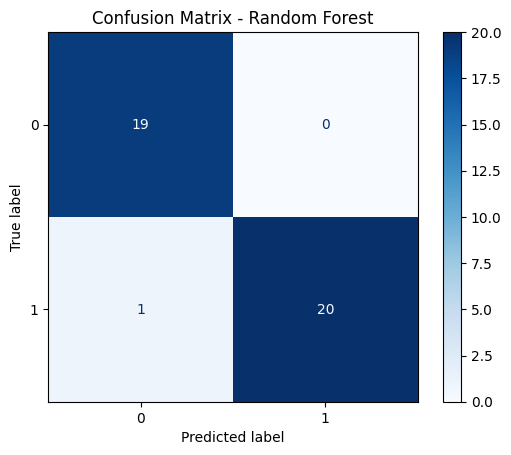

Accuracy Score: 97.50%



In [22]:
rf.fit(X_train, y_train)

prediksi_rf = rf.predict(X_test)
generateClassificationReport(y_test, prediksi_rf, "Random Forest")

## 23. Evaluasi Model Support Vector Machine

Rangkaian tanding validasi bergeser ke kapabilitas penganalisa batas margin, si model komputasi Support Vector Machine (SVM). Dilengkapi amunisi modul kernel fleksibel *Radial Basis Function (RBF)*, algoritma kokoh ini dipertaruhkan membongkar batas kelompok fitur daun *Black Rot* bersinggungan langsung dengan citra daun sehat secara linieritas multidimensi.

Apresiasi analitis patut disematkan saat menyaksikan rekaman persentase `Classification Report` model ini. Hasil kehandalannya dalam meramal tebakan `X_test` berhasil mencetak kesempurnaan akurasi mutlak sebesar **100%**. Begitu juga pada pemaparan *Confusion Matrix*, sel-sel blok kotak salah duga (*False Positives & False Negatives*) tercatat kosong tanpa sisa—menegaskan keunggulan komparatif SVM yang menyalip Random Forest sebelumnya.

=== Laporan Metrik Evaluasi: Support Vector Machine ===
Classification Report:
                     precision    recall  f1-score   support

Grape_black_rot_100       1.00      1.00      1.00        19
     daun_sehat_100       1.00      1.00      1.00        21

           accuracy                           1.00        40
          macro avg       1.00      1.00      1.00        40
       weighted avg       1.00      1.00      1.00        40



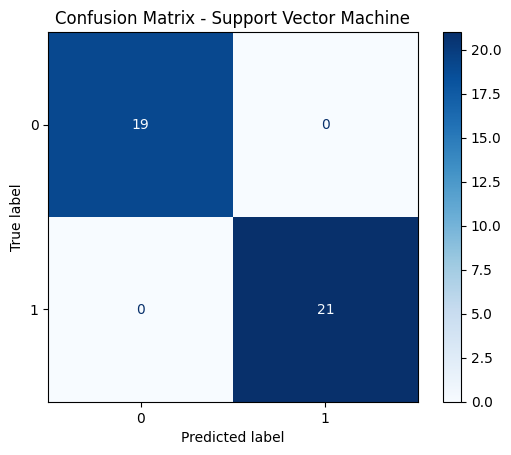

Accuracy Score: 100.00%



In [23]:
svm.fit(X_train, y_train)

prediksi_svm = svm.predict(X_test)
generateClassificationReport(y_test, prediksi_svm, "Support Vector Machine")

## 24. Evaluasi Model K-Nearest Neighbors

Laporan verifikasi terakhir diembankan ke pundak arsitektur pengenalan sederhana tapi presisi, K-Nearest Neighbors (KNN). Pendekatan *lazy-learning* jarak tetangga ini terlahir sangat lemah menghadapi inkonsistensi skala margin, namun amat reaktif mengekstrak fitur spasial yang setara.

Bukti validasi akan tuntas saat menengok evaluasi tebakan persentase angka KNN. Prestasi yang terekam pada layar di bawah memunculkan *Accuracy Score* **100%**! Hasil ini mematahkan keraguan di awal, sekaligus menyertifikasi secara teknis bahwa keberadaan normalisasi jangkauan metrik fitur (*Z-Score Normalization*) yang disematkan tadi memfasilitasi algoritma spasial sederhana seperti KNN ini bekerja super optimal, tak ubahnya kedigdayaan rumit kalkulasi matematis milik model SVM.

=== Laporan Metrik Evaluasi: K-Nearest Neighbors ===
Classification Report:
                     precision    recall  f1-score   support

Grape_black_rot_100       1.00      1.00      1.00        19
     daun_sehat_100       1.00      1.00      1.00        21

           accuracy                           1.00        40
          macro avg       1.00      1.00      1.00        40
       weighted avg       1.00      1.00      1.00        40



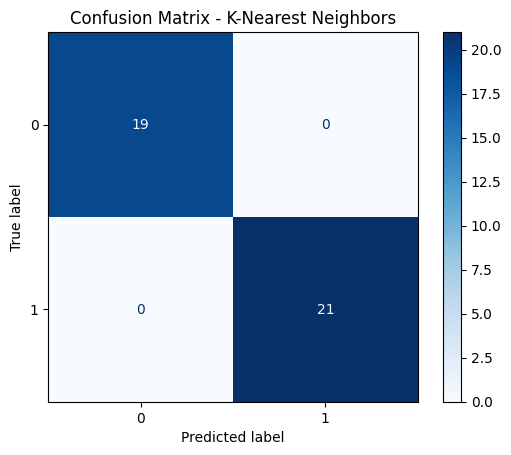

Accuracy Score: 100.00%



In [24]:
knn.fit(X_train, y_train)

prediksi_knn = knn.predict(X_test)
generateClassificationReport(y_test, prediksi_knn, "K-Nearest Neighbors")